Project / Lab 3: Implementing a Simplified Region-based Object Detection (Faster R-CNN style)
Note: A full from-scratch Faster R-CNN is quite complex for a single lab session.
Here we implement a simplified educational version using:
Pre-trained backbone (ResNet50)
Simple anchor-based region proposals (not full RPN training)
ROI pooling + classification head
# Lab 3: Simplified Region-based Object Detection (Faster R-CNN inspired)
#### Goal: Understand region proposals → ROI pooling → classification & box regression


## Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Disable XLA JIT compilation globally, before model definition and compilation
tf.config.optimizer.set_jit(False)

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [ ]:
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_ENABLE_XLA"] = "0"

In [ ]:
import tensorflow as tf

tf.config.optimizer.set_jit(False)
tf.config.run_functions_eagerly(True)

## Load pre-trained backbone (feature extractor)

In [ ]:
backbone = keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(None, None, 3)
)

In [ ]:
# Freeze early layers

for layer in backbone.layers[:100]:
    layer.trainable = False

print("Backbone loaded (ResNet50)")

Backbone loaded (ResNet50)


## Simple Anchor Generator (9 anchors per position)

In [ ]:
class AnchorLayer(layers.Layer):
    def __init__(self, ratios=[0.5,1,2], scales=[0.5,1,2], **kwargs):
        super().__init__(**kwargs)
        self.ratios = tf.constant(ratios, dtype=tf.float32)
        self.scales = tf.constant(scales, dtype=tf.float32)

    def call(self, feature_map):
        shape = tf.shape(feature_map)
        H, W = shape[1], shape[2]

        # normalized grid coordinates
        y = tf.linspace(0.5 / tf.cast(H, tf.float32),
                        (tf.cast(H, tf.float32) - 0.5) / tf.cast(H, tf.float32), H)
        x = tf.linspace(0.5 / tf.cast(W, tf.float32),
                        (tf.cast(W, tf.float32) - 0.5) / tf.cast(W, tf.float32), W)

        yy, xx = tf.meshgrid(y, x, indexing='ij')
        centers = tf.stack([yy, xx], axis=-1)
        centers = tf.reshape(centers, (-1, 2))  # (H*W,2)

        ws = tf.sqrt(tf.reshape(self.scales**2 / self.ratios, (-1,)))
        hs = tf.sqrt(tf.reshape(self.scales**2 * self.ratios, (-1,)))
        num_anchors = tf.size(ws)

        centers_tiled = tf.repeat(centers, repeats=num_anchors, axis=0)
        ws_tiled = tf.tile(ws, [tf.shape(centers)[0]])
        hs_tiled = tf.tile(hs, [tf.shape(centers)[0]])

        y1 = centers_tiled[:,0] - hs_tiled/2
        x1 = centers_tiled[:,1] - ws_tiled/2
        y2 = centers_tiled[:,0] + hs_tiled/2
        x2 = centers_tiled[:,1] + ws_tiled/2

        anchors = tf.stack([y1, x1, y2, x2], axis=-1)
        return tf.clip_by_value(anchors, 0.0, 1.0)


### Simple ROI Pooling layer

In [ ]:
class ROIPooling(layers.Layer):
    def __init__(self, pool_size=(7,7), **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, boxes = inputs  # boxes: (B,N,4) normalized
        batch_size = tf.shape(feature_map)[0]
        num_rois = tf.shape(boxes)[1]

        boxes_flat = tf.reshape(boxes, (-1,4))
        box_indices = tf.repeat(tf.range(batch_size), num_rois)

        pooled = tf.image.crop_and_resize(feature_map, boxes_flat, box_indices, self.pool_size)

        # reshape back to (B, N, pool_h, pool_w, C) for TimeDistributed
        C = tf.shape(feature_map)[-1]
        pooled = tf.reshape(pooled, (batch_size, num_rois, self.pool_size[0], self.pool_size[1], C))
        return pooled

### Build simplified detection head

In [ ]:
# -----------------------------
# 4. Detection head
# -----------------------------
def build_detector(num_classes=21, num_proposals=128):
    inputs = keras.Input(shape=(None, None, 3))
    features = backbone(inputs)

    # Anchors / proposals
    anchors = AnchorLayer()(features)

    # For simplicity: random proposals for now (replace with RPN later)
    proposals = layers.Lambda(
        lambda x: tf.random.uniform((tf.shape(x)[0], num_proposals, 4), 0, 1),
        output_shape=(num_proposals, 4)
    )(features)

    # ROI Pooling
    pooled = ROIPooling(pool_size=(7, 7))([features, proposals])

    # Detection head
    # Flatten/Pool the RoIs for the dense layers
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(pooled)
    x = layers.TimeDistributed(layers.Dense(512, activation='relu'))(x)
    x = layers.TimeDistributed(layers.Dropout(0.5))(x)

    # Final outputs
    cls = layers.TimeDistributed(layers.Dense(num_classes, activation='softmax'), name='cls')(x)
    reg = layers.TimeDistributed(layers.Dense(4 * num_classes), name='reg')(x)

    model = keras.Model(inputs, [cls, reg])
    return model

model = build_detector(num_classes=21)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, None,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ None, 2048)       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 4)    │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling         │ (None, 128, 7, 7, │          0 │ resnet50[0][0],   │
│ (ROIPooling)        │ 2048)             │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 128, 2048) │          0 │ roi_pooling[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 128, 512)  │  1,049,088 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 128, 512)  │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls                 │ (None, 128, 21)   │     10,773 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg                 │ (None, 128, 84)   │     43,092 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,690,665 (94.19 MB)

 Trainable params: 20,555,881 (78.41 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

In [ ]:
def preprocess_image(img, target_size=(512,512)):
    img_resized = tf.image.resize(img, target_size)
    img_resized = img_resized / 255.0  # normalize
    return img_resized

In [ ]:
model.compile(
    optimizer="adam",
    loss=...,
    run_eagerly=True  # optional but safer
)

In [ ]:
# -----------------------------
# 5. Compile model (dummy loss for training demo)
# -----------------------------
def smooth_l1(y_true, y_pred):
    diff = tf.abs(y_true - y_pred)
    less_than_one = tf.cast(tf.less(diff, 1.0), tf.float32)
    loss = less_than_one * 0.5 * diff**2 + (1-less_than_one) * (diff-0.5)
    return tf.reduce_mean(loss)

model.compile(
    optimizer="adam",
    loss="mse",   # or your actual loss
    run_eagerly=True
)


In [ ]:
# ────────────────────────────────────────────────
# 5. Inference demo on sample image
# ────────────────────────────────────────────────
img_path = "/content/andy-holmes-D6TqIa-tWRY-unsplash.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (512, 512))
img_input = np.expand_dims(img_resized.astype(np.float32)/255., 0)

In [ ]:
# Dummy inference (random proposals → random results)
cls, reg = model.predict(img_input)

print("Inference done. (This is simplified – real training needed)")

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Inference done. (This is simplified – real training needed)


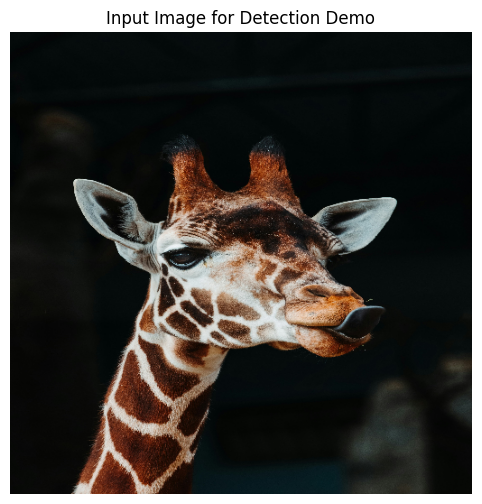

In [ ]:
# Visualize input
plt.figure(figsize=(8,6))
plt.imshow(img_resized)
plt.title("Input Image for Detection Demo")
plt.axis('off')
plt.show()

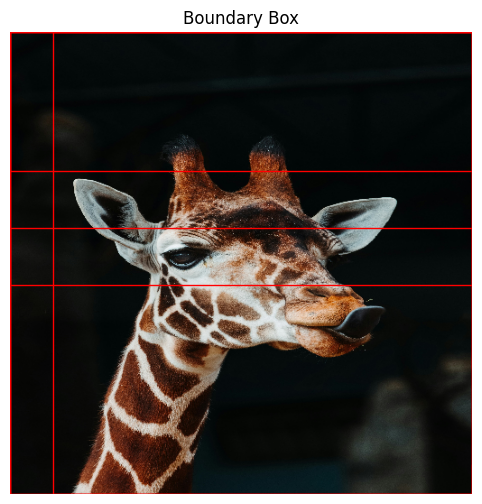

In [ ]:
import matplotlib.patches as patches

# proposals: (batch, num_proposals, 4), random normalized
proposals_np = model.layers[2].output  # This is Lambda layer for proposals
# But symbolic tensor, so we can’t access directly
# Instead, let's use the predicted reg output as dummy boxes:

# Convert predictions to dummy boxes for visualization
# reg: (B*num_proposals, 4*num_classes)
# We'll just take first 4 numbers for demo
boxes = reg[0].reshape(-1, 4)  # (num_proposals, 4) – just for demo

# clip between 0-1
boxes = np.clip(boxes, 0, 1)

fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(img_resized)

H, W, _ = img_resized.shape

for box in boxes[:10]:  # show first 10 boxes only
    y1, x1, y2, x2 = box
    rect = patches.Rectangle(
        (x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
        linewidth=1, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

plt.title("Boundary Box")
plt.axis('off')
plt.show()
